# Module 3.4 — Higher-Order Schemes and TVD Limiters

**The problem you've been ignoring since Module 1.6:**
The upwind scheme is stable but diffusive — it smears sharp features. Central schemes are accurate but oscillate near discontinuities. In real CFD (combustion fronts, shocks, steep concentration gradients), you need both: second-order accuracy in smooth regions AND no oscillations near sharp features.

**Godunov's theorem (1959):** No *linear* scheme can be both second-order accurate and free of spurious oscillations (monotone). This is a mathematical theorem, not a deficiency of specific schemes — it is a fundamental limit.

**The solution:** use *nonlinear* schemes that adapt their behaviour based on the local gradient. These are called **flux limiters** or **TVD (Total Variation Diminishing) schemes**.

**Roadmap:**
1. The diffusion-dispersion dilemma — why no linear scheme works near discontinuities
2. Total Variation — what it measures and why decreasing TV is the right property
3. The flux limiter framework — how to blend upwind and high-order in one formula
4. Common limiters — Minmod, Van Leer, Superbee, MC
5. The Sweby diagram — a graphical classification of all TVD schemes
6. QUICK scheme — third-order accurate but not TVD
7. Implementation and comparison

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. The Diffusion-Dispersion Dilemma

### Analogy: blurring vs. ringing

Think of a sharp black-to-white edge in a photograph.

**Diffusion** is like applying a Gaussian blur — the edge softens and spreads. Sharp features are lost, but there are no artifacts. This is what 1st-order upwind does to a steep gradient: it smears it over several cells.

**Dispersion** is like over-sharpening in a photo editor — the edge stays sharp, but a dark halo appears on the bright side and a bright halo on the dark side. These halos are not in the original image; the algorithm invented them. This is what Lax-Wendroff does near a discontinuity: the solution stays sharp but grows unphysical oscillations on both sides.

```
Original:     ──────┐
                    └──────

Upwind (diffusion):    ──────╲
                              ╲──────   (smeared but calm)

Lax-Wendroff (dispersion):  ──────┐~
                                ~  └──────  (sharp but oscillates)
```

Neither is acceptable when you need sharp AND oscillation-free.

### Modified equation analysis

Every finite-difference scheme actually solves a **modified PDE** — not the original one, but one with extra derivative terms:

**Upwind (FTBS)** actually solves:
$$\frac{\partial u}{\partial t} + c\frac{\partial u}{\partial x} = \underbrace{\frac{c\Delta x}{2}(1-\nu)\frac{\partial^2 u}{\partial x^2}}_{\text{numerical diffusion}}$$

At CFL $\nu = 1$, diffusion vanishes — upwind is exact. At $\nu < 1$, everything gets smeared.

**Lax-Wendroff** actually solves:
$$\frac{\partial u}{\partial t} + c\frac{\partial u}{\partial x} = \underbrace{-\frac{c\Delta x^2}{6}(1-\nu^2)\frac{\partial^3 u}{\partial x^3}}_{\text{numerical dispersion}}$$

A third-derivative causes different wave frequencies to travel at different speeds — the sharp edge arrives intact but trailing oscillations appear behind it.

---

## 2. Total Variation — Measuring Oscillations

### Analogy: hiking trail elevation

Imagine walking along a trail and recording your elevation at every step.

- **Total Variation** = total vertical distance you climbed (ups AND downs added together, not cancelled)
- A smooth hill from valley to peak: TV = just the height difference (you only go up once)
- A jagged ridge with many small peaks and valleys: TV is much larger — you climbed and descended many times

$$TV(u) = \sum_i \lvert u_{i+1} - u_i \rvert$$

A numerical oscillation adds a small up-and-down — it increases TV without being in the original data.

### TVD property

A scheme is **TVD** (Total Variation Diminishing) if:

$$TV(u^{n+1}) \leq TV(u^n) \quad \text{for all } n$$

**What this guarantees:** the solution cannot invent new peaks and valleys that were not in the initial condition. An existing peak can flatten or merge with another, but the solver can never create a new one from nothing.

**Godunov's theorem (1959):** No *linear* scheme can be both TVD and second-order accurate. To get both, the scheme must be nonlinear — it must adapt based on the local solution. That adaptation is the limiter.

---

## 3. The Flux Limiter Framework

### Analogy: adaptive cruise control

You are driving on a motorway. In clear, straight road (smooth flow):
- Cruise control engages — you drive at full speed with high precision

Approaching a sharp bend or sudden obstacle (steep gradient / discontinuity):
- Cruise control disengages — you brake and drive cautiously (1st-order, safe)

The **gradient ratio** $r$ is the sensor that detects what kind of road is ahead. The **limiter function** $\phi(r)$ is the throttle response.

### The blending formula

$$\phi_e = \phi_P + \underbrace{\frac{1}{2}\,\psi(r)\,(1-\nu)}_{\text{limiter scales correction}} \cdot (\phi_P - \phi_W)$$

Or equivalently as a flux blend:

$$F_{i+1/2} = F^{\text{upwind}}_{i+1/2} + \psi(r_i)\left(F^{\text{high}}_{i+1/2} - F^{\text{upwind}}_{i+1/2}\right)$$

- $\psi(r) = 0$ → pure 1st-order upwind (safe near shocks)
- $\psi(r) = 1$ → full 2nd-order correction (accurate in smooth regions)

### The gradient ratio $r$

$$r_i = \frac{\phi_P - \phi_W}{\phi_E - \phi_P}$$

$r$ compares the gradient **behind** cell P to the gradient **ahead** of cell P:

```
Smooth region (r ≈ 1):         Steep gradient / extremum (r < 0):

  ●──●──●──●──●                    ●──●      ●──●
   gradients equal                       ●        ← peak: gradients flip sign
```

- $r \approx 1$: gradients equal on both sides → smooth → $\psi = 1$ (high-order)
- $r < 0$: gradient changes sign → local extremum → $\psi = 0$ (pure upwind)
- $r \to 0$: gradient ahead much larger than behind → sudden steepening → $\psi \to 0$

**When $r \to 0$:** the correction term $\psi(r) \cdot (\phi_P - \phi_W) \to 0$, so the face value falls back to $\phi_P$ — pure 1st-order upwind. No correction, no oscillation.

---

## 4. Common Limiter Functions

### Analogy: how aggressively should you brake?

All TVD limiters must lie inside the **Sweby region** (see diagram below). Think of the Sweby region as the safe braking envelope — stay inside it and you are guaranteed no new oscillations.

- **Minmod** — brakes hard at the first sign of trouble. Very safe, but slows down (diffusive) even on gentle bends.
- **Van Leer** — smooth, progressive braking. Good balance between caution and speed.
- **Superbee** — almost never brakes. Keeps features sharp, but can over-compress smooth Gaussians into step-like shapes.
- **MC (monotonized central)** — a well-tuned compromise; good default for general flows.

| Limiter | $\phi(r)$ | Character |
|---------|-----------|-----------|
| **Minmod** | $\max(0,\, \min(1, r))$ | Most diffusive TVD — safest choice |
| **Van Leer** | $\dfrac{r + \lvert r \rvert}{1 + \lvert r \rvert}$ | Smooth curve, second-order, popular |
| **Superbee** | $\max(0,\, \min(2r,1),\, \min(r,2))$ | Least diffusive TVD — sharpest features |
| **MC** (monotonized central) | $\max(0,\,\min((1+r)/2,\, 2,\, 2r))$ | Good all-round balance |

All limiters satisfy $\phi(1) = 1$ (second-order in smooth regions) and $\phi(r) = 0$ for $r < 0$ (first-order near extrema).

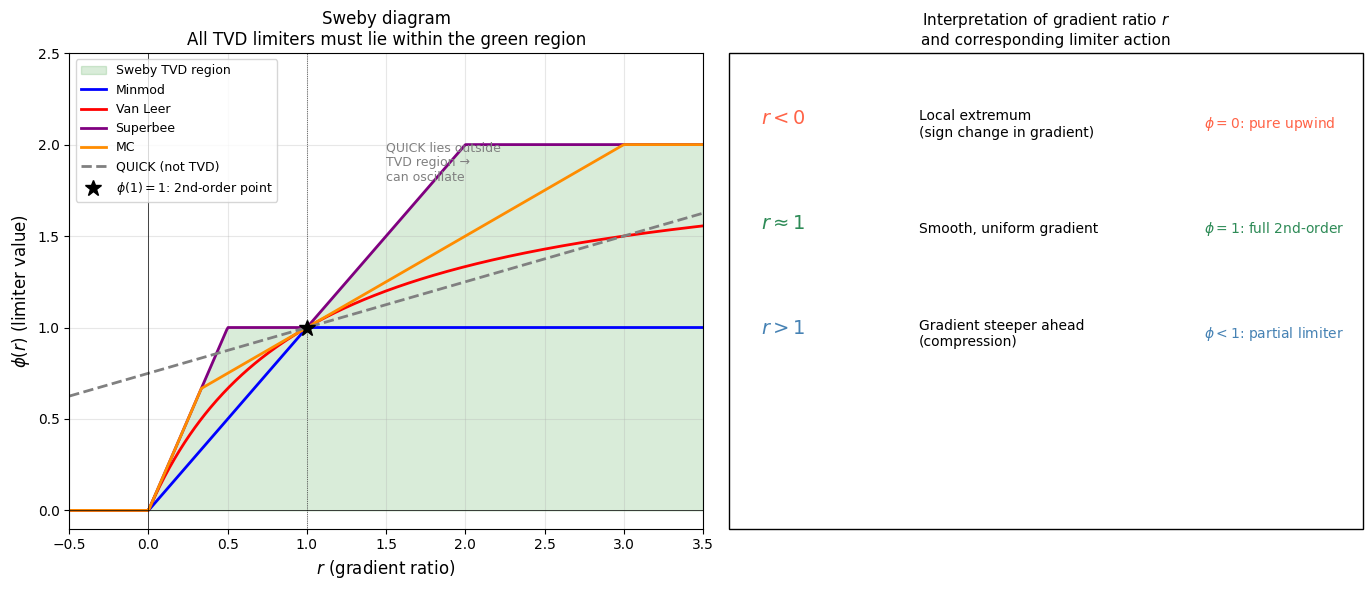

Key insight: limiters are NONLINEAR — φ(r) depends on the local solution.
This is what allows second-order accuracy in smooth regions + TVD everywhere.
Linear schemes cannot achieve both simultaneously (Godunov theorem).


In [2]:
# ── Limiter functions and the Sweby diagram ───────────────────────────────────

r = np.linspace(-0.5, 3.5, 500)

limiters = {
    'Minmod':    np.maximum(0, np.minimum(1, r)),
    'Van Leer':  (r + np.abs(r)) / (1 + np.abs(r) + 1e-12),
    'Superbee':  np.maximum(0, np.maximum(np.minimum(2*r, 1), np.minimum(r, 2))),
    'MC':        np.maximum(0, np.minimum((1+r)/2, np.minimum(2, 2*r))),
    'QUICK (not TVD)': 0.75 + 0.25*r,   # can exceed Sweby region
}
colors = ['blue', 'red', 'purple', 'darkorange', 'gray']
styles = ['-', '-', '-', '-', '--']

# Sweby TVD region bounds
upper_bound = np.maximum(0, np.maximum(np.minimum(2*r, 1), np.minimum(r, 2)))
lower_bound = np.zeros_like(r)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ── Sweby diagram ─────────────────────────────────────────────────────────────
ax1.fill_between(r, lower_bound, upper_bound, alpha=0.15, color='green',
                  label='Sweby TVD region')
for (name, phi), col, sty in zip(limiters.items(), colors, styles):
    ax1.plot(r, phi, color=col, lw=2, linestyle=sty, label=name)

# Mark second-order locus: φ(1) = 1
ax1.axvline(1, color='k', lw=0.5, linestyle=':')
ax1.plot(1, 1, 'k*', markersize=12, label='$\\phi(1)=1$: 2nd-order point')
ax1.axhline(0, color='k', lw=0.5); ax1.axvline(0, color='k', lw=0.5)
ax1.set_xlabel('$r$ (gradient ratio)', fontsize=12)
ax1.set_ylabel('$\\phi(r)$ (limiter value)', fontsize=12)
ax1.set_title('Sweby diagram\nAll TVD limiters must lie within the green region')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
ax1.set_xlim(-0.5, 3.5); ax1.set_ylim(-0.1, 2.5)
ax1.text(1.5, 1.8, 'QUICK lies outside\nTVD region →\ncan oscillate', fontsize=9, color='gray')

# ── Interpretation of r ───────────────────────────────────────────────────────
ax2.axis('off')
cases_r = [
    ('$r < 0$', 'Local extremum\n(sign change in gradient)', '$\\phi = 0$: pure upwind', 'tomato'),
    ('$r \\approx 1$', 'Smooth, uniform gradient', '$\\phi = 1$: full 2nd-order', 'seagreen'),
    ('$r > 1$', 'Gradient steeper ahead\n(compression)', '$\\phi < 1$: partial limiter', 'steelblue'),
]
y_pos = 0.85
for r_label, description, phi_val, color in cases_r:
    ax2.text(0.05, y_pos, r_label, fontsize=14, color=color, fontweight='bold',
             transform=ax2.transAxes)
    ax2.text(0.30, y_pos, description, fontsize=10, transform=ax2.transAxes, va='center')
    ax2.text(0.75, y_pos, phi_val, fontsize=10, color=color, transform=ax2.transAxes, va='center')
    y_pos -= 0.22

ax2.set_title('Interpretation of gradient ratio $r$\nand corresponding limiter action', fontsize=11)
ax2.add_patch(plt.Rectangle((0,0), 1, 1, fill=False, transform=ax2.transAxes, clip_on=False))

plt.tight_layout()
plt.show()

print('Key insight: limiters are NONLINEAR — φ(r) depends on the local solution.')
print('This is what allows second-order accuracy in smooth regions + TVD everywhere.')
print('Linear schemes cannot achieve both simultaneously (Godunov theorem).')

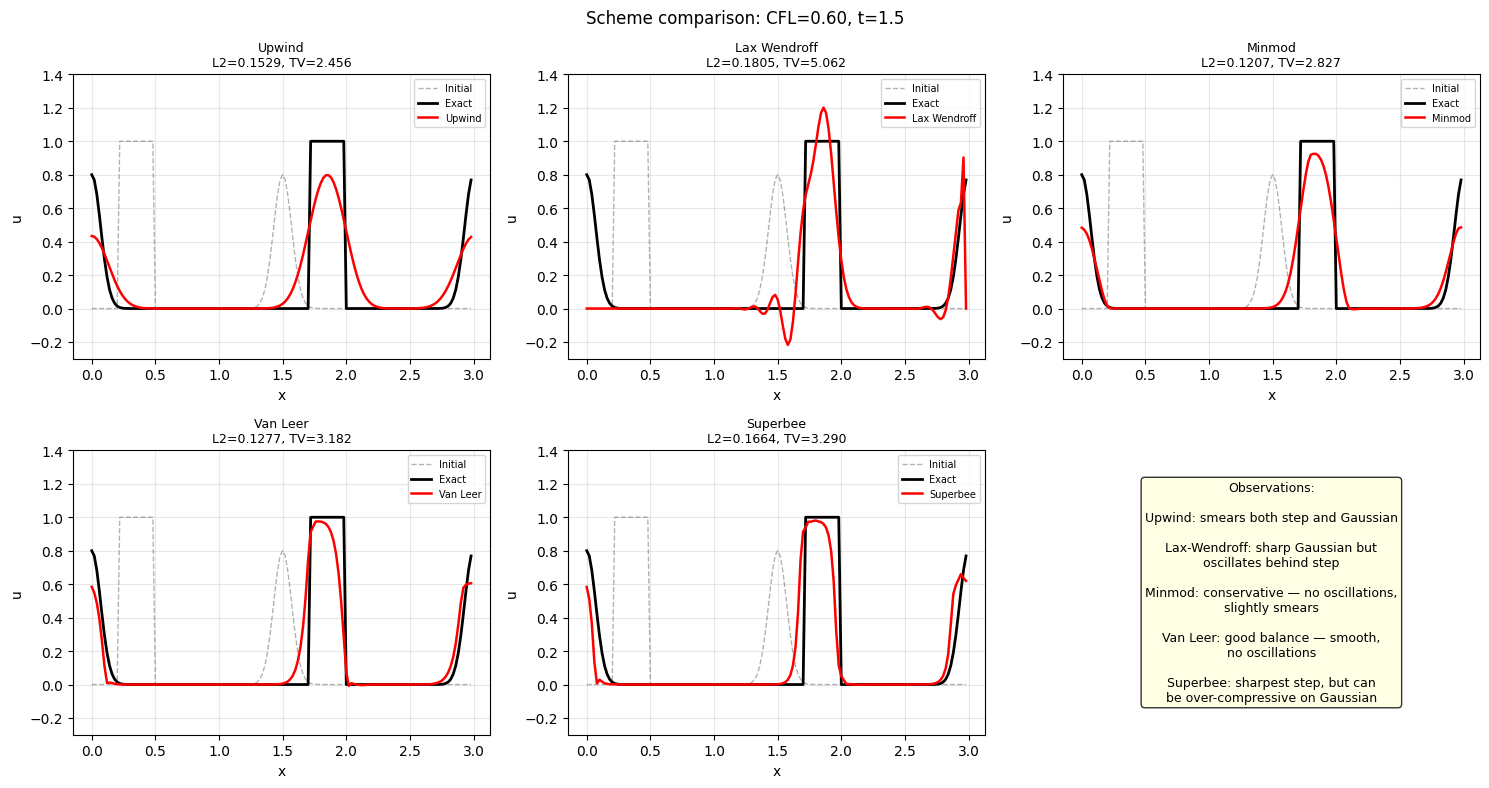

In [3]:
# ── Scheme comparison on a mixed test (step + Gaussian) ──────────────────────

def advect_tvd(u0, c, dx, dt, nt, scheme='upwind'):
    """1D advection with various flux treatments."""
    u  = u0.copy()
    nu = c * dt / dx

    def phi(r, name):
        if name == 'minmod':
            return np.maximum(0, np.minimum(1, r))
        elif name == 'van_leer':
            return (r + np.abs(r)) / (1 + np.abs(r) + 1e-12)
        elif name == 'superbee':
            return np.maximum(0, np.maximum(np.minimum(2*r,1), np.minimum(r,2)))
        elif name == 'mc':
            return np.maximum(0, np.minimum((1+r)/2, np.minimum(2, 2*r)))

    for _ in range(nt):
        un = u.copy()

        if scheme == 'upwind':
            u[1:] = un[1:] - nu*(un[1:] - un[:-1])
            u[0]  = un[0]  - nu*(un[0]  - un[-1])

        elif scheme == 'lax_wendroff':
            u[1:-1] = (un[1:-1]
                       - nu/2*(un[2:]-un[:-2])
                       + nu**2/2*(un[2:]-2*un[1:-1]+un[:-2]))
            u[0] = un[0]; u[-1] = un[-1]

        elif scheme in ('minmod', 'van_leer', 'superbee', 'mc'):
            # Flux-limited scheme (c > 0: upwind = left cell)
            u_new = np.zeros_like(un)
            N     = len(un)
            for i in range(N):
                im1 = (i-1) % N;  im2 = (i-2) % N
                ip1 = (i+1) % N
                denom = un[i] - un[im1] + 1e-12
                r_i   = (un[im1] - un[im2]) / denom
                phi_i = phi(r_i, scheme)
                denom2 = un[ip1] - un[i] + 1e-12
                r_im1  = (un[i] - un[im1]) / denom2
                phi_im1 = phi(r_im1, scheme)
                F_right = c*(un[i]   + 0.5*phi_i  *(1-nu)*(un[i]-un[im1]))
                F_left  = c*(un[im1] + 0.5*phi_im1*(1-nu)*(un[im1]-un[im2]))
                u_new[i] = un[i] - nu*(F_right - F_left)/c
            u = u_new
    return u

# ── Setup ─────────────────────────────────────────────────────────────────────
N   = 150
L   = 3.0;   dx = L/N
x   = np.linspace(0, L, N, endpoint=False)
c   = 1.0;   dt = 0.6*dx/c;   T = 1.5
nt  = int(T/dt)

# Mixed IC: step (hard) + Gaussian (smooth)
u0 = np.zeros(N)
u0[(x>0.2)&(x<0.5)] = 1.0
u0 += 0.8*np.exp(-((x-1.5)**2)/0.01)

# Exact: shift by c*T mod L
x_ex = (x - c*T) % L
u_ex = np.zeros(N)
u_ex[(x_ex>0.2)&(x_ex<0.5)] = 1.0
u_ex += 0.8*np.exp(-((x_ex-1.5)**2)/0.01)

schemes = ['upwind', 'lax_wendroff', 'minmod', 'van_leer', 'superbee']
results = {s: advect_tvd(u0, c, dx, dt, nt, s) for s in schemes}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes_flat = axes.ravel()

for ax, scheme in zip(axes_flat, schemes):
    u_num = results[scheme]
    l2 = np.sqrt(np.mean((u_num-u_ex)**2))
    tv = np.sum(np.abs(np.diff(u_num)))
    ax.plot(x, u0, 'k--', lw=1, alpha=0.3, label='Initial')
    ax.plot(x, u_ex, 'k-', lw=2, label='Exact')
    ax.plot(x, u_num, 'r-', lw=1.8,
            label=f'{scheme.replace("_"," ").title()}')
    ax.set_title(f'{scheme.replace("_"," ").title()}\nL2={l2:.4f}, TV={tv:.3f}',
                 fontsize=9)
    ax.set_xlabel('x'); ax.set_ylabel('u')
    ax.legend(fontsize=7); ax.set_ylim(-0.3, 1.4)
    ax.grid(True, alpha=0.3)

axes_flat[-1].axis('off')
axes_flat[-1].text(0.5, 0.5,
    'Observations:\n\n'
    'Upwind: smears both step and Gaussian\n\n'
    'Lax-Wendroff: sharp Gaussian but\noscillates behind step\n\n'
    'Minmod: conservative — no oscillations,\nslightly smears\n\n'
    'Van Leer: good balance — smooth,\nno oscillations\n\n'
    'Superbee: sharpest step, but can\nbe over-compressive on Gaussian',
    ha='center', va='center', fontsize=9, transform=axes_flat[-1].transAxes,
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle(f'Scheme comparison: CFL={c*dt/dx:.2f}, t={T}', fontsize=12)
plt.tight_layout()
plt.show()

## 5. QUICK Scheme — Third-Order Accurate

### Analogy: predicting your next position using GPS history

1st-order upwind says: "I am at position P — assume the face value is just P."

QUICK says: "I have GPS data from W (two steps back), P (last step), and I can also see E (one step ahead). Fit a smooth curve through all three and read off the face value."

Using more history (and one look-ahead) gives a more accurate prediction — but it requires looking downstream, which causes problems at boundaries and near shocks.

**QUICK** = Quadratic Upstream Interpolation for Convective Kinematics (Leonard, 1979)

Fits a **quadratic** through 2 upstream + 1 downstream cell:

$$\phi_e = \frac{6}{8}\phi_P + \frac{3}{8}\phi_E - \frac{1}{8}\phi_W \quad \text{(flow going right, } c > 0\text{)}$$

In FVM compass notation (W = west, P = current, E = east):

```
Flow  →
  ●──────────●──────────|face──────●
  W          P          e          E

φ_e = (6/8)·φ_P  +  (3/8)·φ_E  −  (1/8)·φ_W
       ↑ dominant     ↑ small        ↑ curvature
       upstream       downstream     correction
```

- The **−(1/8)φ_W** term is the curvature correction from fitting a quadratic
- This makes QUICK **3rd-order accurate** in space
- QUICK is **not TVD** — its limiter line $\psi(r) = 0.75 + 0.25r$ exits the Sweby TVD region for small $r$, causing oscillations near discontinuities
- Stencil uses a downstream cell (φ_E), so special treatment is needed at the outlet boundary

**When to use QUICK:** smooth flows with no shocks or fronts — turbulent channel flow, pipe flow, flows where extra accuracy matters and discontinuities are absent.

## 6. MUSCL — Slope-Limited Reconstruction

### Analogy: room temperature gradient

Imagine a corridor of rooms. Each room has a thermometer that records the average temperature inside.

**1st-order (piecewise constant):** assume the whole room is at the average temperature. The wall between two rooms jumps abruptly from one average to the next.

**MUSCL (piecewise linear):** assume the temperature varies linearly inside the room — slightly cooler near one wall, slightly warmer near the other. The face value is read off this slope, giving a smoother, more accurate estimate.

**Limiter:** if the neighbouring rooms are wildly different in temperature (like a room next to a furnace), the slope estimate inside our room is limited — we can't trust a large extrapolation when the neighbours disagree.

```
  Piecewise constant (1st order):        Piecewise linear (MUSCL, 2nd order):

  ──┬───────┬───────┬──                  ──┬──╱───╲──╱───╲──╱──
    │  φ_W  │  φ_P  │  φ_E               W ╱   P ╲ ╱  E  ╲╱
  ──┴───────┴───────┴──                  ──╱─────╲╱─────────╲──
```

**MUSCL** = Monotone Upstream-centered Schemes for Conservation Laws (van Leer, 1979)

MUSCL is the **FVM-native form** of TVD — instead of a per-face limiter, it reconstructs a limited slope inside each cell.

### The reconstruction formula

Inside cell P, reconstruct a slope $\Delta_P$ using a limiter:

$$\Delta_P = \text{limiter}(\phi_P - \phi_W,\; \phi_E - \phi_P)$$

The face values at the edges of cell P are:

$$\phi_P^R = \phi_P + \frac{1}{2}\Delta_P \quad \text{(right face)}$$
$$\phi_P^L = \phi_P - \frac{1}{2}\Delta_P \quad \text{(left face)}$$

The flux at the east face uses $\phi_P^R$ from the left cell and $\phi_E^L$ from the right cell:

$$F_e = F\!\left(\phi_P^R,\; \phi_E^L\right)$$

### How the limiter protects you

With minmod:

$$\Delta_P = \text{minmod}(\phi_P - \phi_W,\; \phi_E - \phi_P) = \max\!\left(0,\; \min(\phi_P-\phi_W,\; \phi_E-\phi_P)\right)$$

- Left and right gradients agree → both positive, minmod picks the smaller → safe slope → 2nd-order
- Gradients disagree (one positive, one negative → local peak) → minmod returns 0 → flat cell → 1st-order upwind

This is the room analogy: when both neighbours agree on the direction of change, you trust the slope. When they disagree, you play it safe and treat the cell as flat.

### MUSCL vs TVD flux limiter

| | TVD flux limiter | MUSCL |
|---|---|---|
| Where limiter acts | At each face | Inside each cell (slope) |
| What is limited | The face correction | The reconstructed slope |
| Used in | Finite difference codes | Finite volume codes (OpenFOAM, SU2) |
| Accuracy | 2nd-order + TVD | 2nd-order + TVD |

Both achieve the same result — they are two formulations of the same idea.

**OpenFOAM:** `Gauss limitedLinear 1` uses MUSCL-style reconstruction with the van Leer limiter internally.

## Summary

| Property | Upwind | Lax-Wendroff | TVD (Van Leer) |
|----------|--------|-------------|----------------|
| Order (smooth) | 1st | 2nd | 2nd |
| Stability | $\nu \leq 1$ | $\nu \leq 1$ | $\nu \leq 1$ |
| Near discontinuities | Diffusive (smears) | Dispersive (oscillates) | ✅ Non-oscillatory |
| Conserves TV? | ✅ Yes | ❌ No | ✅ Yes |
| Nonlinear? | No | No | ✅ Yes (by design) |

**OpenFOAM scheme names:**
- `linear`: central — 2nd order, may oscillate (use with care)
- `upwind`: 1st order upwind — safe but diffusive
- `linearUpwind`: 2nd order upwind — good for smooth flows
- `limitedLinear`: Van Leer-like TVD — recommended default for convection
- `Gauss limitedLinear 1`: OpenFOAM syntax for TVD convection scheme

---
**Next:** Module 3.5 — Multigrid Methods: why Gauss-Seidel stalls on smooth errors and how V-cycles fix it in $O(N)$ operations.